In [1]:
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error


In [2]:
insurance_data = pd.read_csv("E:\\archive (2)\\insurance.csv")

In [3]:
X = insurance_data.drop(columns = ["charges"])
Y = insurance_data["charges"]
X = pd.get_dummies(X , columns= ["region"], drop_first = True , dtype = int)
X["smoker"] = X["smoker"].map({"yes":1 , "no":0})
X["sex"] = X["sex"].map({"female":1 , "male":0})

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2 , random_state = 42)

In [15]:
alpha = [0.1,0.001,0.002,2,3,4,5]
mses = []
for a in alpha:
    lasso_model = Lasso(alpha = a)
    lasso_model.fit(X_train,Y_train)
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(Y_test,y_pred)
    print(mse)
    mses.append(mse)

33597770.05720262
33596924.388283744
33596932.92669768
33614211.308740854
33623037.56043786
33631952.08146762
33639750.85985903


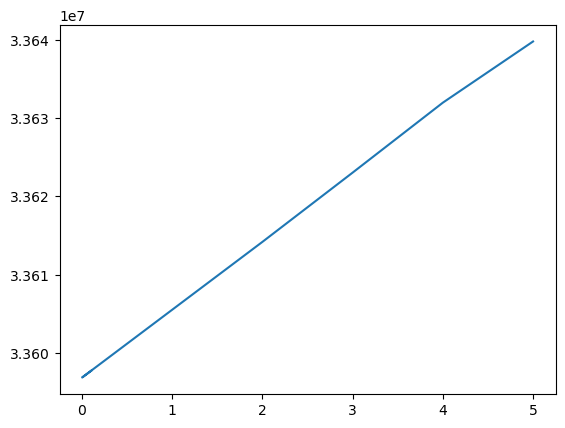

In [18]:
import matplotlib.pyplot as plt
plt.plot(alpha , mses )
plt.show()

In [22]:
from sklearn.linear_model import LassoCV
a = [ 0.001,0.1,0.02,2,3,4,5,0.0001]
lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter = 1000,
    random_state = 42
)
lasso_cv_model.fit(X_train,Y_train)
print("best alpha value :", lasso_cv_model.alpha_)
lasso_cv_model.predict(X_test)
mse = mean_squared_error(Y_test,y_pred)
print(mse)

best alpha value : 5.0
33639750.85985903
